# Project: House Price Prediction

This is one of the most common industry and interview examples.

Problem Statement : Predict the price of a house based on:

- Area
- Bedrooms
- Bathrooms
- Age of House

Target: Price

  > [Dataset url](https://www.kaggle.com/datasets/harishkumardatalab/housing-price-prediction)

# Model 1: Simple Linear Regression

Goal

Predict price using only one feature.

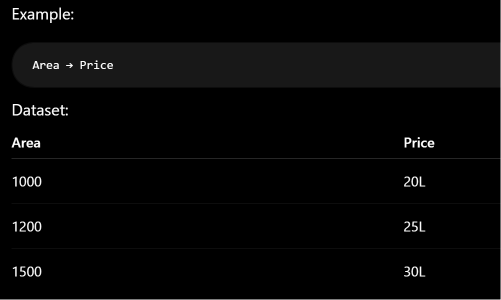

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



In [4]:
df = pd.read_csv('/content/Housing.csv')  # by this command we can render the csv file data into runtime colab
df.head() # this command is used to render top 5 row's

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
print("Info table")
df.info()

print("--------------------------------------------------")
print("Describe table")
df.describe()

Info table
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
--------------------------------------------------
Describe table


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.isnull() #this will show the table (if null : True else : False)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum() # this command is to give total number of null values in a column

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Text(0.5, 1.0, 'Scatter plot between area & price')

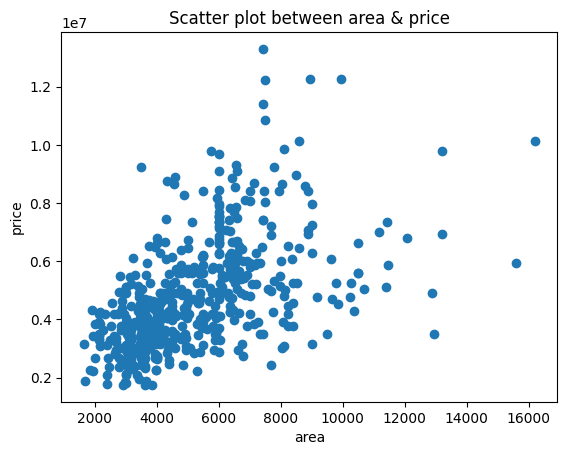

In [12]:
#now let's see the trend between the area & price with the help of scatter plot
# why scatter plot only ? bcoz -> both area , price dtype is int64 so we prefer scatter plot to find relationships
plt.scatter(df['area'],df['price'])
plt.xlabel('area')
plt.ylabel('price')
plt.title('Scatter plot between area & price')

# 👉 Do points roughly form a straight line?

# If yes → Linear Regression may work.
but it was false bcoz they are not forming any stright line so linear will not work , so we shift to futher

we can justify by seeing graph but let's see numerically also


In [13]:
X = df[["area"]]
y = df["price"]

# split the data from training
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

#now declare the model
model = LinearRegression()
# now fit the model
model.fit(X_train,y_train)


LinearRegression()

In [15]:
#now predect on the test data
y_pred = model.predict(X_test)

In [19]:
# now evaluate the linear regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2_percentage = r2_score(y_test, y_pred) * 100
#Print the final performance results
print(f"Model Accuracy (R² Score): {r2_percentage:.2f}%")
print("---------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Accuracy (R² Score): 27.29%
---------------------------------------
Mean Absolute Error (MAE): 1474748.1338
Mean Squared Error (MSE): 3675286604768.1851
Root Mean Squared Error (RMSE): 1917103.7021


#so our accuracy is 27% very low now go to
#Model 2: Multiple Linear Regression
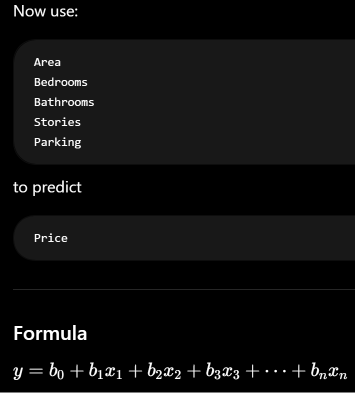

In [20]:
df=pd.read_csv('/content/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


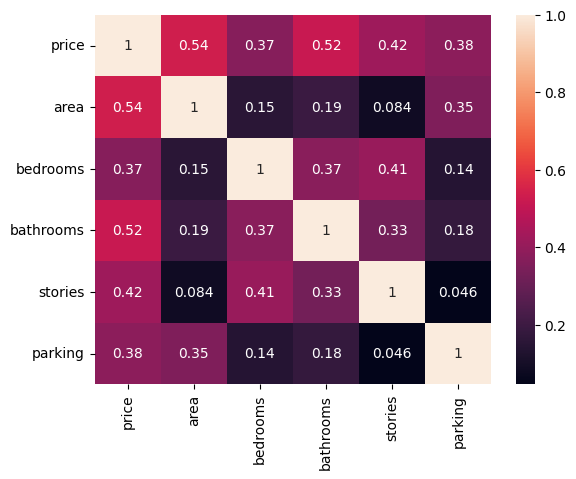

In [24]:
#ok now let's see which which columns have relation's b/w them with the help of heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [26]:
# Convert binary categorical columns to numerical (0 or 1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert 'furnishingstatus' using one-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

X = df.drop("price",axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [27]:
#now predect on the test data
y_pred = model.predict(X_test)

In [28]:
# now evaluate the linear regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2_percentage = r2_score(y_test, y_pred) * 100
#Print the final performance results
print(f"Model Accuracy (R² Score): {r2_percentage:.2f}%")
print("---------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Accuracy (R² Score): 65.29%
---------------------------------------
Mean Absolute Error (MAE): 970043.4039
Mean Squared Error (MSE): 1754318687330.6633
Root Mean Squared Error (RMSE): 1324506.9601


# from liner we can see progess in multiple (65.29%) which is good
Problem with Multiple Linear Regression

Some relationships are not linear.

So lets see:
# Model 3: Polynomial Regression

Example Dataset:
| Experience | Salary |
| ---------- | ------ |
| 1          | 25K    |
| 2          | 30K    |
| 3          | 40K    |
| 5          | 80K    |
| 10         | 2L     |

Curve instead of straight line.

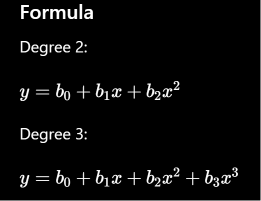

In [29]:
# same data fetching & splittin everything is same

# so jump intomodel
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

In [31]:
X_poly = poly.fit_transform(X)

# Example:
# Input:
# x = 5
# Converted to:
# 1
# x
# x²
# becomes
# 1
# 5
# 25

In [32]:
model = LinearRegression()

model.fit(X_poly,y)

LinearRegression()

In [34]:
#now predect on the test data
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

In [35]:
# now evaluate the linear regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2_percentage = r2_score(y_test, y_pred) * 100
#Print the final performance results
print(f"Model Accuracy (R² Score): {r2_percentage:.2f}%")
print("---------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Accuracy (R² Score): 75.23%
---------------------------------------
Mean Absolute Error (MAE): 806506.7813
Mean Squared Error (MSE): 1251835780755.9272
Root Mean Squared Error (RMSE): 1118854.6737




1.   Model 1 :  27.29%
2.   Model 2 :  65.29%
3.   Model 3 :  75.23%



#

In [38]:
print("Completed Linear , Multiple , Polynomial Regression . Please Suppor Path4DSA")

Completed Linear , Multiple , Polynomial Regression . Please Suppor Path4DSA
